# IMPORTS

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.linear_model import LinearRegression
import itertools

# Loading the DataFrame

In [2]:
df = pd.read_csv('../data/final/master_football_dataset.csv')
df1 = pd.read_csv('../data/final/master_football_engineered.csv')

# Exploratory Data Analysis

In [3]:
df.dtypes

year                    int64
competition_id         object
club_id                 int64
club_name              object
matches_played          int64
wins                    int64
draws                   int64
losses                  int64
goals_for               int64
goals_against           int64
points                  int64
goal_difference         int64
position                int64
league                 object
country_name           object
transfer_spending     float64
squad_market_value      int64
num_players_valued      int64
season                 object
clean_sheets            int64
dtype: object

In [4]:
df.describe()

,year,club_id,matches_played,wins,draws,losses,goals_for,goals_against,points,goal_difference,position,transfer_spending,squad_market_value,num_players_valued,clean_sheets
count,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000,978.000000,9.780000e+02,9.780000e+02,978.000000,978.000000
mean,2018.490798,1229.814928,36.983640,13.839468,9.304703,13.839468,51.105317,51.105317,50.823108,0.000000,10.297546,3.904840e+07,5.994589e+08,49.907975,10.005112
std,2.869459,2877.217631,2.073308,6.033495,2.926111,5.494186,17.084538,13.304718,17.181087,26.372499,5.671168,5.637264e+07,6.336495e+08,18.183240,4.018506
min,2014.000000,3.000000,27.000000,2.000000,2.000000,0.000000,20.000000,17.000000,13.000000,-69.000000,1.000000,0.000000e+00,1.295000e+07,14.000000,1.000000
25%,2016.000000,148.000000,38.000000,10.000000,7.000000,10.000000,39.000000,42.000000,39.000000,-18.000000,5.000000,4.762500e+06,1.851812e+08,37.000000,7.000000
50%,2018.000000,509.000000,38.000000,12.500000,9.000000,14.000000,48.000000,51.000000,47.000000,-4.000000,10.000000,1.787000e+07,3.619375e+08,47.000000,10.000000
75%,2021.000000,1041.000000,38.000000,18.000000,11.000000,18.000000,60.000000,60.000000,62.000000,15.000000,15.000000,4.986750e+07,7.538750e+08,59.000000,12.000000
max,2023.000000,23826.000000,38.000000,32.000000,19.000000,29.000000,118.000000,104.000000,100.000000,89.000000,20.000000,5.743500e+08,3.966350e+09,117.000000,26.000000


- For transfer spending, the max value is €574M. This could be due to purchase capacity of bigger / top tier clubs.

- In sqaud market value, €3.96B reflects the extreme financial strength of elite clubs with a high-performing sqaud.

- For points, the mean is 49.64. This aligns with the mid table points average that most of the teams have at the end of a football season.

- Mean for goals for and against is 50. This should be equal because they both should tally mathematically.

- Also the mean of goal difference is zero, confirms the data accuracy.

In [5]:
df[['transfer_spending','squad_market_value','points']].agg(['min','max'])

,transfer_spending,squad_market_value,points
min,0.0,12950000,13
max,574350000.0,3966350000,100


- The range of transfer spending and squad market value is huge, indicating a  financial dispairity between clubs. This is due to purchase capacity of bigger clubs.
- The range in points indicates the obvious difference in sporting performances.

## Univariate Analysis

### Histograms

#### Squad Market Value

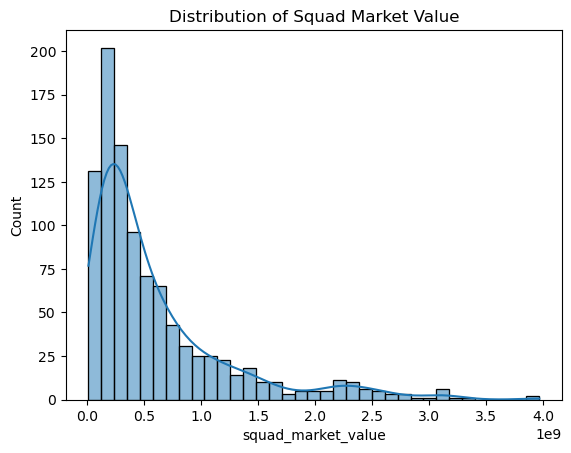

In [6]:
sns.histplot(df['squad_market_value'], kde=True)
plt.title("Distribution of Squad Market Value")
plt.show()

In [63]:
(df['squad_market_value'] < 500_000_000).mean()

np.float64(0.6114519427402862)

- Most teams have low-squad values, while few clubs have extreme high-value squads
- More than half of the clubs, i.e., about 61% are worth under €500M.
- The maximum squad value extends upto almost €4B, so there is an extreme wealth gap between the teams

#### Transfer Spending

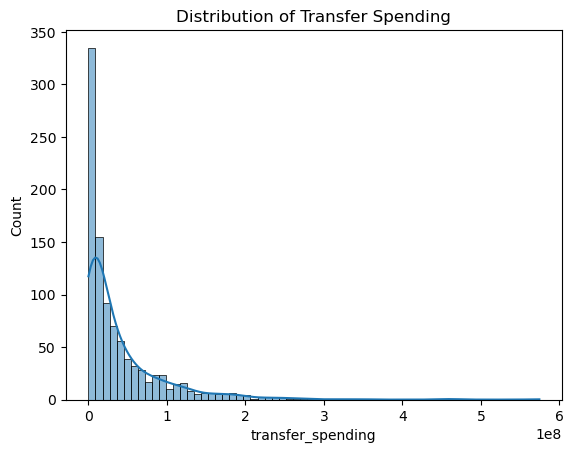

In [7]:
sns.histplot(df['transfer_spending'], kde=True)
plt.title("Distribution of Transfer Spending")
plt.show()

In [64]:
(df['transfer_spending'] < 100_000_000).mean()

np.float64(0.8936605316973415)

- Most clubs, about 90%, spend less than €100M, with only a few spending very large sums, similar to sqaud value.
- The maximum transfer spend is around €580M, so there is a significant amount of financial inequality and purchase capacity. 

#### Number of players valued

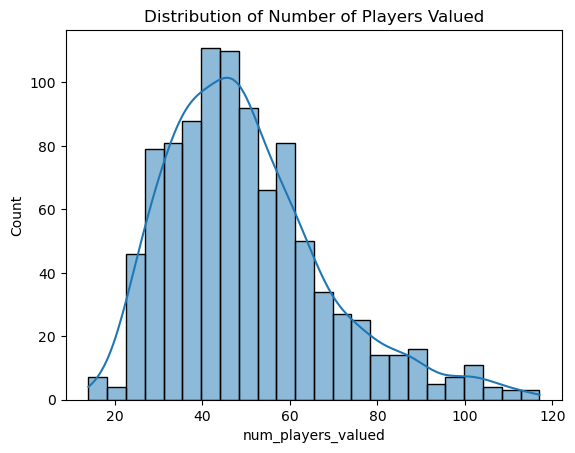

In [8]:
sns.histplot(df['num_players_valued'], kde=True)
plt.title("Distribution of Number of Players Valued")
plt.show()

In [68]:
# Typical range (30–60 players)
typical_pct = ((df['num_players_valued'] >= 30) & (df['num_players_valued'] <= 60)).mean()

# Large squads (top 10%)
p90 = df['num_players_valued'].quantile(0.90)
large_pct = (df['num_players_valued'] > p90).mean()

# Very large squads (top 5%)
p95 = df['num_players_valued'].quantile(0.95)
very_large_pct = (df['num_players_valued'] > p95).mean()

typical_pct, large_pct, very_large_pct, p90, p95

(np.float64(0.6666666666666666),
 np.float64(0.09713701431492842),
 np.float64(0.050102249488752554),
 np.float64(75.0),
 np.float64(86.14999999999998))

- Approximately 67% of teams have between 30–60 players valued, indicating that most clubs maintain relatively consistent squad sizes.
- Only ~9.7% of teams have more than 75 players valued (top 10%), suggesting that large squad sizes are uncommon.
- Just ~5.0% of teams exceed 86 players valued (top 5%), highlighting that unusually large squads are rare and represent clear outliers.
- Given that a typical matchday squad consists of ~25 players, higher counts likely reflect the inclusion of reserve and youth academy players in squad valuation.

#### Number of points

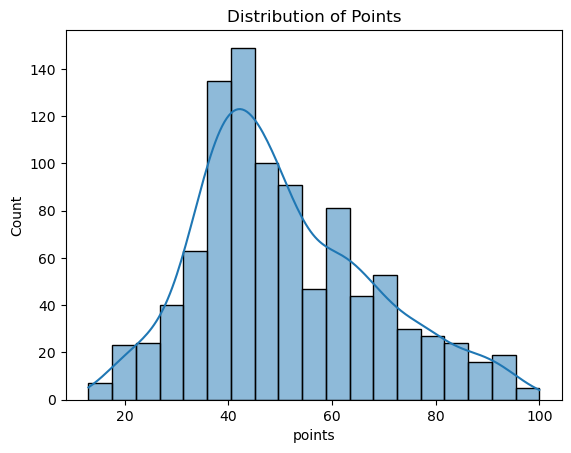

In [9]:
sns.histplot(df['points'], kde=True)
plt.title("Distribution of Points")
plt.show()

- Most teams finish with mid-range points (around 40–60).
- Only a small number of teams achieve very high or very low points totals. 
- Very high points = top 4 finish, very low points = relegation.

### Boxplots

#### Transfer Spending

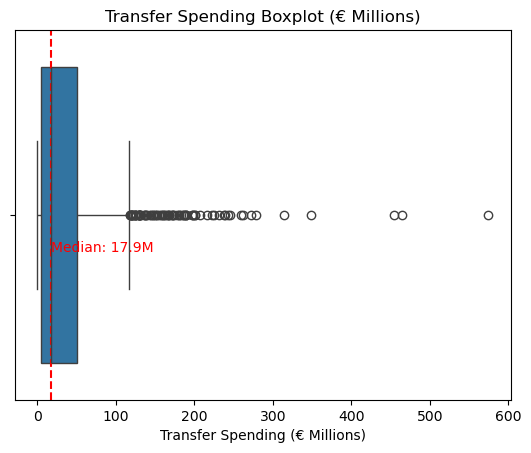

In [10]:
# convert to millions
df['spending_m'] = df['transfer_spending'] / 1e6

# plot
sns.boxplot(x=df['spending_m'])

# median
median = df['spending_m'].median()

# add vertical line
plt.axvline(median, color='red', linestyle='--')

# annotation
plt.text(median, 0.1, f"Median: {median:.1f}M", color='red')

plt.title("Transfer Spending Boxplot (€ Millions)")
plt.xlabel("Transfer Spending (€ Millions)")

plt.show()

- Most clubs spend relatively low amounts, wit majority clustered below €50M.
- Fewer clubs spend extremely high amounts, these are outliers.
- These outliers indicate the financial inequality of the clubs.

In [11]:
df[['squad_market_value','transfer_spending','points']].corr()

,squad_market_value,transfer_spending,points
squad_market_value,1.000000,0.673993,0.627874
transfer_spending,0.673993,1.000000,0.436493
points,0.627874,0.436493,1.000000


- The correlation between 
    - squad value and points is ~0.63 (Strong)
    - transfer spending and points is ~0.44 (Moderate)
    - sqaud value and spending is ~0.67 (Strong)

## Bivariate Analysis

### Scatter Plot

#### Spending vs Performance (Points)

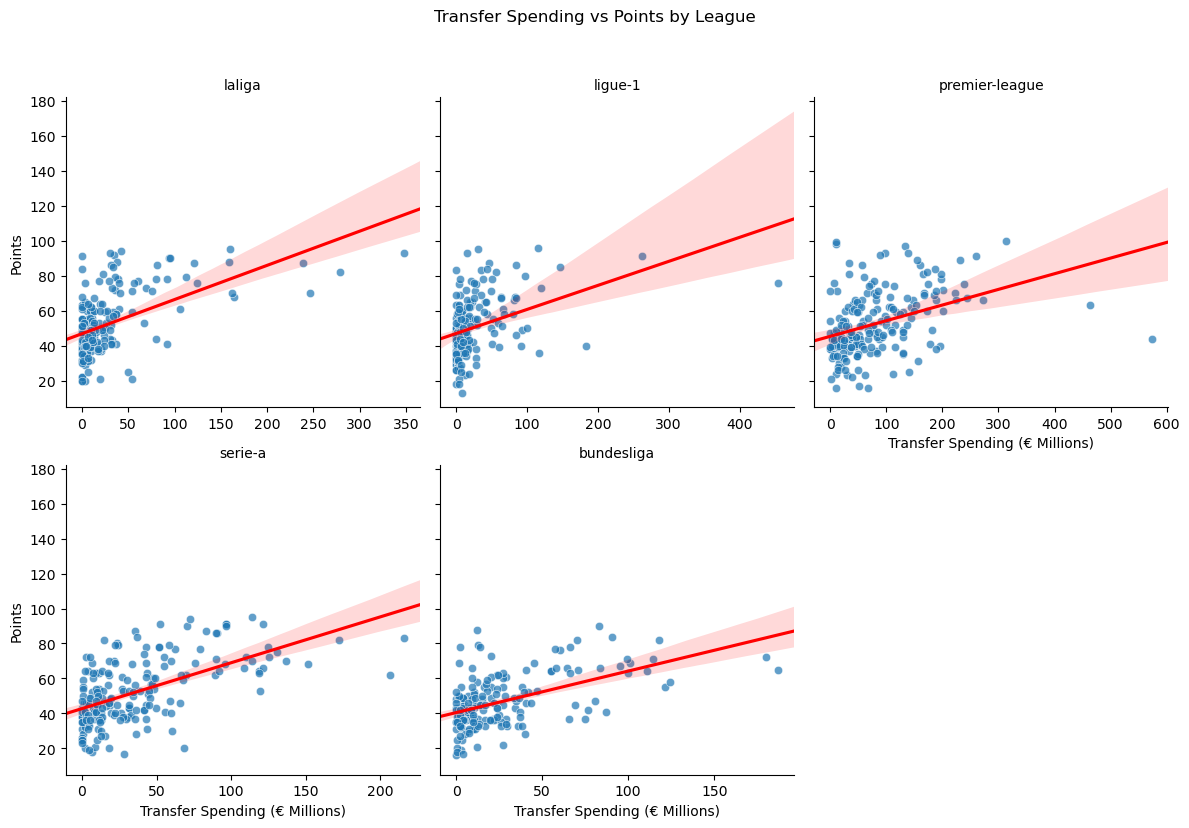

In [12]:
# convert to millions
df['spending_m'] = df['transfer_spending'] / 1e6

# faceted scatter plots by league
g = sns.FacetGrid(df, col="league", col_wrap=3, height=4, sharex=False, sharey=True)
g.map_dataframe(sns.scatterplot, x="spending_m", y="points", alpha=0.7)
g.map_dataframe(sns.regplot, x="spending_m", y="points", scatter=False, color="red", truncate=False)

g.set_axis_labels("Transfer Spending (€ Millions)", "Points")
g.set_titles("{col_name}")
g.fig.suptitle("Transfer Spending vs Points by League", y=1.03)

plt.tight_layout()
plt.show()

#### How often higher transfer spend leads to better performance? (higher = relative comparisons between two teams)

In [73]:
df['spending_m'] = df['transfer_spending'] / 1e6
def spending_success_rate(df_league):
    pairs = list(itertools.combinations(df_league.index, 2))
    correct = 0
    total = 0
    
    for i, j in pairs:
        s1, s2 = df_league.loc[i, 'spending_m'], df_league.loc[j, 'spending_m']
        p1, p2 = df_league.loc[i, 'points'], df_league.loc[j, 'points']
        
        if s1 != s2:
            total += 1
            if (s1 > s2 and p1 > p2) or (s2 > s1 and p2 > p1):
                correct += 1
                
    return correct / total

df.groupby('league').apply(spending_success_rate)

/var/folders/7q/2wc5cs997tqgvx852w8yrf1r0000gn/T/ipykernel_58902/2784585608.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('league').apply(spending_success_rate)


league
bundesliga        0.660037
laliga            0.683150
ligue-1           0.649166
premier-league    0.650359
serie-a           0.696832
dtype: float64

- 🇩🇪 Bundesliga
    - In the Bundesliga, higher spending results in better performance in about 66% of cases, indicating a moderate relationship with some level of competitive balance.

- 🇪🇸 La Liga 
    - Higher transfer spending leads to better performance in around 68% of cases, indicating a strong financial influence, though outcomes are still not fully consistent

- 🇫🇷 Ligue 1
    - Transfer spending predicts performance in approximately 65% of cases, but the league structure is skewed, with a few high-spending teams dominating results

- 🇬🇧 Premier League
    - Despite high spending across many clubs, transfer spending only translates into better performance in about 65% of cases, reflecting strong competition and unpredictability..

- 🇮🇹 Serie A
    - Serie A shows one of the strongest relationships, with higher spending leading to better performance in around 70% of cases, suggesting spending is relatively effective in this league.

#### Squad Value vs Performance (Points)

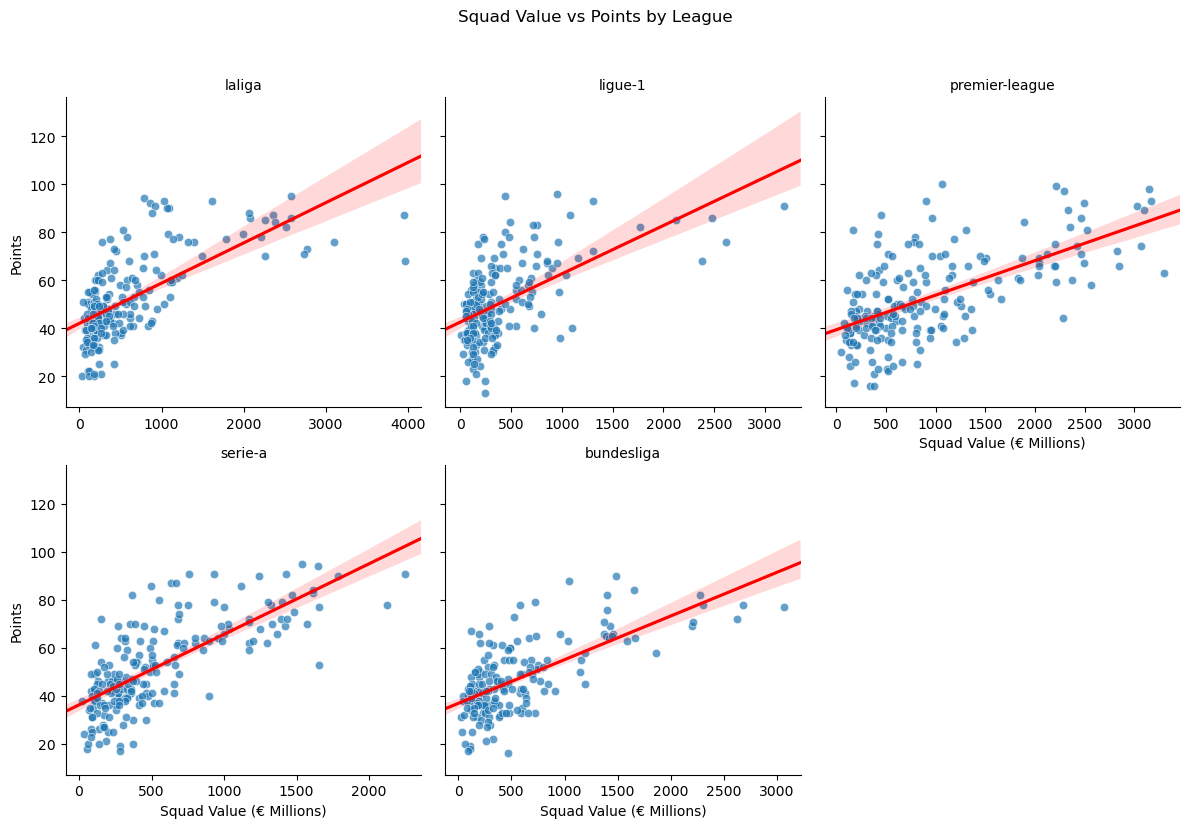

In [13]:
# convert to millions
df['svalue_m'] = df['squad_market_value'] / 1e6

# faceted scatter plots by league
g = sns.FacetGrid(df, col="league", col_wrap=3, height=4, sharex=False, sharey=True)
g.map_dataframe(sns.scatterplot, x="svalue_m", y="points", alpha=0.7)
g.map_dataframe(sns.regplot, x="svalue_m", y="points", scatter=False, color="red", truncate=False)

g.set_axis_labels("Squad Value (€ Millions)", "Points")
g.set_titles("{col_name}")
g.fig.suptitle("Squad Value vs Points by League", y=1.03)

plt.tight_layout()
plt.show()

- Squad value is a stronger predictor of points than transfer spending across all leagues
- The relationship is tighter and more consistent, i.e., clubs with expensive squads almost always finish near the top
- This suggests that accumulated squad wealth matters more than what the teams spend in any single window (on transfers).

#### Transfer Spending vs Position

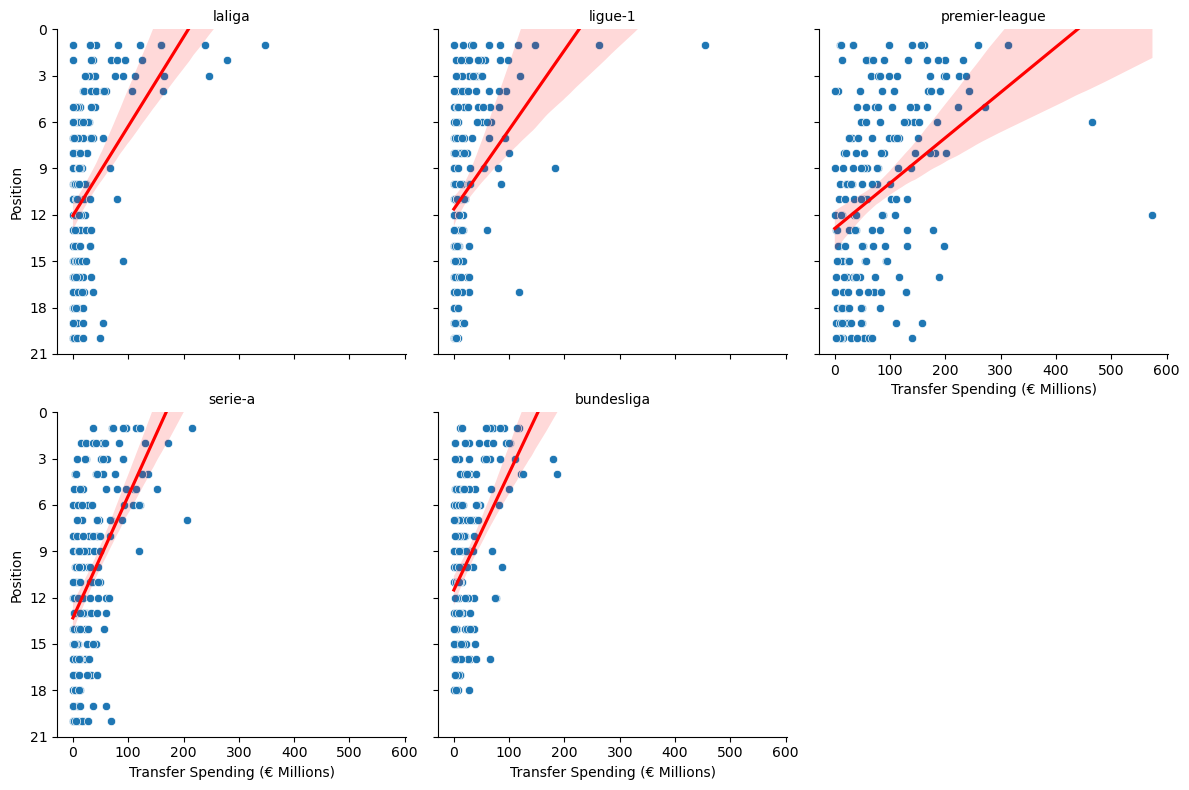

In [14]:
df['position'] = df['position'].astype(int)
df['spending_m'] = df['transfer_spending'] / 1e6

g = sns.FacetGrid(df, col="league", col_wrap=3, height=4)
g.map_dataframe(sns.scatterplot, x="spending_m", y="position")
g.map_dataframe(sns.regplot, x="spending_m", y="position",
                scatter=False, color="red", truncate=True)
g.set_axis_labels("Transfer Spending (€ Millions)", "Position")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.set_ylim(21, 0)  # add padding instead of (20,1)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

- Higher spending generally leads to a better (lower number) finishing position, but it's not guaranteed.
- The relationship is weaker than squad value vs points. So a big 'one-season splurge' doesn't always move the teams up the table.
- There are visible outliers in every league; clubs that spent heavily but still finished mid-table or lower.

### League-level Analysis

#### Transfer spending

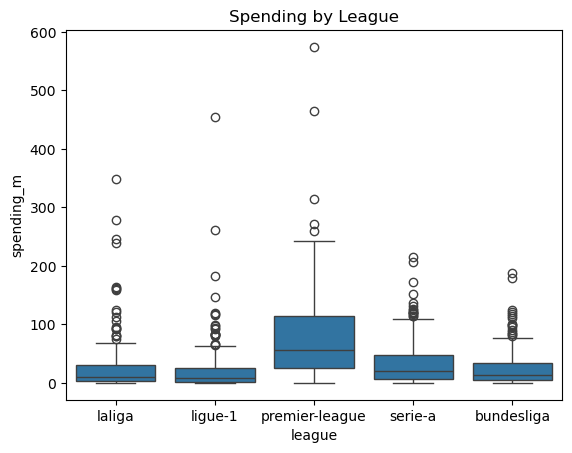

In [15]:
df['spending_m'] = df['transfer_spending'] / 1e6
sns.boxplot(x='league', y='spending_m', data=df)
plt.title("Spending by League")
plt.show()

- The Premier League has the highest and most consistent spending levels across clubs
- Bundesliga clubs spend the least on average, yet remain competitive, same applies to Serie A
- Ligue 1 shows the widest gap between its biggest spender (PSG) and the rest.
- La Liga seem to be a moderate spending league on average.


#### Points

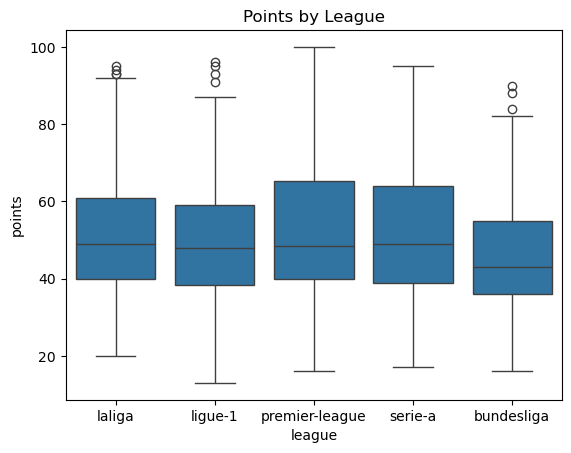

In [16]:
sns.boxplot(x='league', y='points', data=df)
plt.title("Points by League")
plt.show()

- Note 
    - Premier League (England): 20 teams
    - La Liga (Spain): 20 teams
    - Serie A (Italy): 20 teams
    - Ligue 1 (France): 18 teams (reduced from 20 in 2023)
    - Bundesliga (Germany): 18 teams

- Points distributions are similar across leagues. Mid-table performance looks the same everywhere

- Bundesliga shows a slightly more compressed distribution of points, indicating that teams are more closely matched in performance. 
- Aside from top teams like Bayern Munich, the rest of the league tends to be tightly clustered, suggesting a more competitive mid-table compared to other leagues.

#### Squad Value

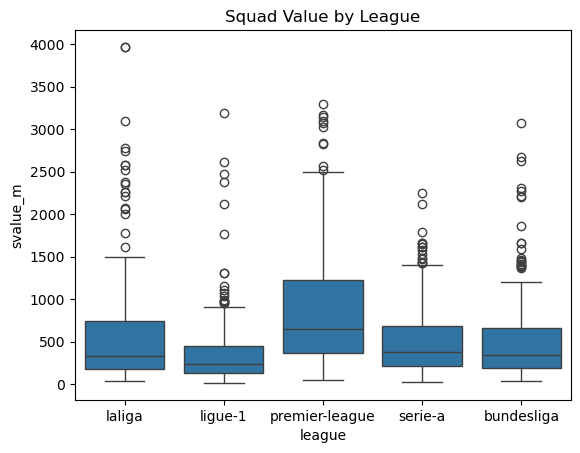

In [17]:
df['svalue_m'] = df['squad_market_value'] / 1e6
sns.boxplot(x='league', y='svalue_m', data=df)
plt.title("Squad Value by League")
plt.show()

- The Premier League has the highest squad values by a clear margin, indicating significantly greater financial capacity compared to other leagues. This aligns with its consistently higher transfer spending, suggesting that greater investment translates into more valuable squads.
- According to Deloitte Football Money League report 2026, there are 9 teams from Premier League alone in top 20 clubs generating high revenue.
- Ligue 1 shows the most extreme outlier (due to PSG) sitting far above every other club in the league
- Bundesliga has the most evenly distributed squad values, fewer extremes at the top.
- La Liga’s high-value outliers are driven by a small number of consistently dominant clubs, with teams like Real Madrid, Barcelona, and Atlético Madrid repeatedly appearing at the top across seasons.

In [70]:
df.groupby('club_name')['squad_market_value'].mean().sort_values(ascending=False)

club_name
Real Madrid FC       2.103145e+09
Bayern Munich        1.997962e+09
Manchester United    1.952758e+09
Manchester City      1.941032e+09
FC Barcelona         1.936115e+09
                         ...     
Nancy                4.020000e+07
Cesena               3.290000e+07
Córdoba CF           3.180000e+07
Carpi                2.065000e+07
GFC Ajaccio          1.295000e+07
Name: squad_market_value, Length: 160, dtype: float64

In [71]:
df[df['league'] == 'laliga'].sort_values('squad_market_value', ascending=False)

,year,competition_id,club_id,club_name,matches_played,wins,draws,losses,goals_for,goals_against,...,league,country_name,transfer_spending,squad_market_value,num_players_valued,season,clean_sheets,spending_m,svalue_m,points_per_million
394,2018,ES1,418,Real Madrid FC,38,21,5,12,63,46,...,laliga,Spain,164750000.0,3966350000,35,2018/19,12,164.75,3966.35,0.412747
392,2018,ES1,131,FC Barcelona,38,26,9,3,90,36,...,laliga,Spain,120900000.0,3959700000,38,2018/19,17,120.90,3959.70,0.719603
393,2018,ES1,13,Atlético Madrid,38,22,10,6,55,29,...,laliga,Spain,124500000.0,3097850000,48,2018/19,20,124.50,3097.85,0.610442
687,2021,ES1,131,FC Barcelona,38,21,10,7,68,38,...,laliga,Spain,69000000.0,2773800000,46,2021/22,11,69.00,2773.80,1.057971
688,2021,ES1,13,Atlético Madrid,38,21,8,9,65,43,...,laliga,Spain,75700000.0,2741700000,59,2021/22,12,75.70,2741.70,0.937913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,2015,ES1,2448,Sporting Gijón,38,10,9,19,40,62,...,laliga,Spain,0.0,65400000,20,2015/16,7,0.00,65.40,NaN
109,2015,ES1,472,UD Las Palmas,38,12,8,18,45,53,...,laliga,Spain,5400000.0,55500000,25,2015/16,11,5.40,55.50,8.148148
303,2017,ES1,12321,Girona FC,38,14,9,15,50,59,...,laliga,Spain,8750000.0,45100000,26,2017/18,11,8.75,45.10,5.828571
18,2014,ES1,3302,UD Almería,38,8,8,22,35,64,...,laliga,Spain,0.0,44850000,28,2014/15,8,0.00,44.85,NaN


#### Financial Inequality across different Leagues

In [60]:
(df.groupby('league')['transfer_spending'].std() /
 df.groupby('league')['transfer_spending'].mean()
).sort_values(ascending=False)

league
ligue-1           1.952760
laliga            1.800876
bundesliga        1.252161
serie-a           1.131890
premier-league    0.970614
Name: transfer_spending, dtype: float64

/var/folders/7q/2wc5cs997tqgvx852w8yrf1r0000gn/T/ipykernel_58902/2371991331.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cv, x='league', y='cv', palette='coolwarm')


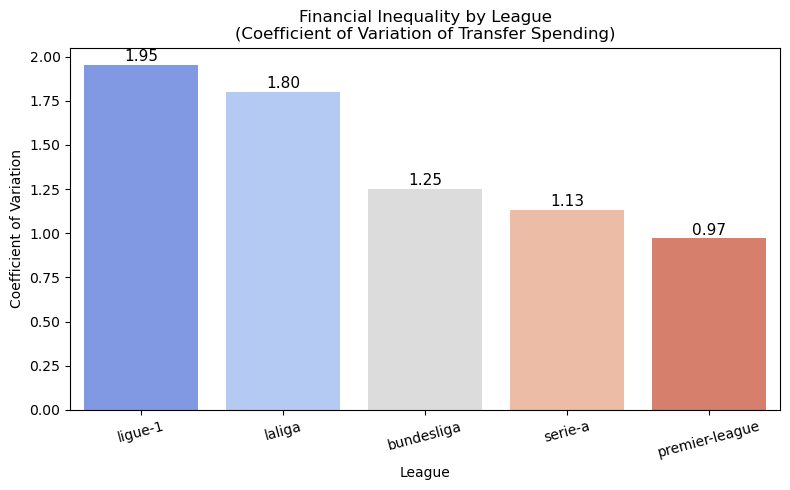

In [19]:
cv = df.groupby('league')['transfer_spending'].std() / df.groupby('league')['transfer_spending'].mean()
cv = cv.sort_values(ascending=False).reset_index()
cv.columns = ['league', 'cv']

plt.figure(figsize=(8, 5))
sns.barplot(data=cv, x='league', y='cv', palette='coolwarm')
plt.title('Financial Inequality by League\n(Coefficient of Variation of Transfer Spending)')
plt.xlabel('League')
plt.ylabel('Coefficient of Variation')
plt.xticks(rotation=15)

for i, row in cv.iterrows():
    plt.text(i, row['cv'] + 0.02, f"{row['cv']:.2f}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

- Ligue 1 is the most financially unequal league. This is expected because Middle-East owned PSG's spending is so dominant it distorts the entire league.
- The Premier League is actually the most equal, its TV money distribution from popularity means even smaller clubs can spend competitively
- La Liga sits in the middle, historically dominated by two clubs but with other spenders emerging 

### Efficiency Analysis

#### Points per 100M Squad Value

In [20]:
df['points_per_million'] = np.where(
    df['squad_market_value'] > 0,
    df['points'] / (df['squad_market_value'] / 1e6),
    np.nan
)

# keep only clubs with at least €100M squad value
efficiency_table = df[df['squad_market_value'] >= 100_000_000] \
    .sort_values('points_per_million', ascending=False)

efficiency_table[['club_name', 'league', 'season', 'squad_market_value', 'points', 'points_per_million']].head(10)

,club_name,league,season,squad_market_value,points,points_per_million
277,RB Leipzig,bundesliga,2016/17,118725000,67,0.564329
163,Sassuolo,serie-a,2015/16,108700000,61,0.561178
47,Swansea City,premier-league,2014/15,102640000,56,0.545596
26,Montpellier,ligue-1,2014/15,111175000,56,0.503710
8,Málaga CF,laliga,2014/15,101075000,50,0.494682
25,Bordeaux,ligue-1,2014/15,127700000,63,0.493344
138,Leicester City,premier-league,2015/16,165475000,81,0.489500
28,Rennes,ligue-1,2014/15,102600000,50,0.487329
7,Celta Vigo,laliga,2014/15,107600000,51,0.473978
259,Atalanta,serie-a,2016/17,152525000,72,0.472054


- Smaller clubs with modest squads who still achieve strong points in a season are the most efficient
- RB Leipzig and Sassuolo are the clubs that were built on smart recruitment and tactical structure rather than star-player power. This challenges the assumption that teams need a €1B squad to compete on high level.


#### Points per 10M Transfer Spend

In [21]:
df['points_per_million'] = np.where(
    df['transfer_spending'] > 0,
    df['points'] / (df['transfer_spending'] / 1e6),
    np.nan
)

# keep only clubs with at least €10M spending
efficiency_table = df[df['transfer_spending'] >= 10_000_000] \
    .sort_values('points_per_million', ascending=False)

efficiency_table[['club_name', 'league', 'season', 'transfer_spending', 'points', 'points_per_million']].head(10)

,club_name,league,season,transfer_spending,points,points_per_million
530,Liverpool,premier-league,2019/20,10400000.0,99,9.519231
178,Bayern Munich,bundesliga,2015/16,12000000.0,88,7.333333
102,Athletic Club Bilbao,laliga,2015/16,10000000.0,62,6.200000
592,Real Sociedad,laliga,2020/21,10000000.0,62,6.200000
80,Bayern Munich,bundesliga,2014/15,13000000.0,79,6.076923
314,Paris Saint-Germain FC,ligue-1,2017/18,16000000.0,93,5.812500
139,Arsenal,premier-league,2015/16,12500000.0,71,5.680000
64,Napoli,serie-a,2014/15,11300000.0,63,5.575221
472,Bayern Munich,bundesliga,2018/19,14000000.0,78,5.571429
159,Napoli,serie-a,2015/16,15000000.0,82,5.466667


- Liverpool 2019/20 and Bayern Munich 2015/16 top this list since they had world-class teams that barely needed any spending that season.
- These are clubs whose previous investments had already built a winning team, reflecting their smart long-term planning.
- Spending less and winning more is achievable, but only with the right squad already in place.

### Time Trend Analysis

#### Average Transfer Spend and Squad Value over Time by League

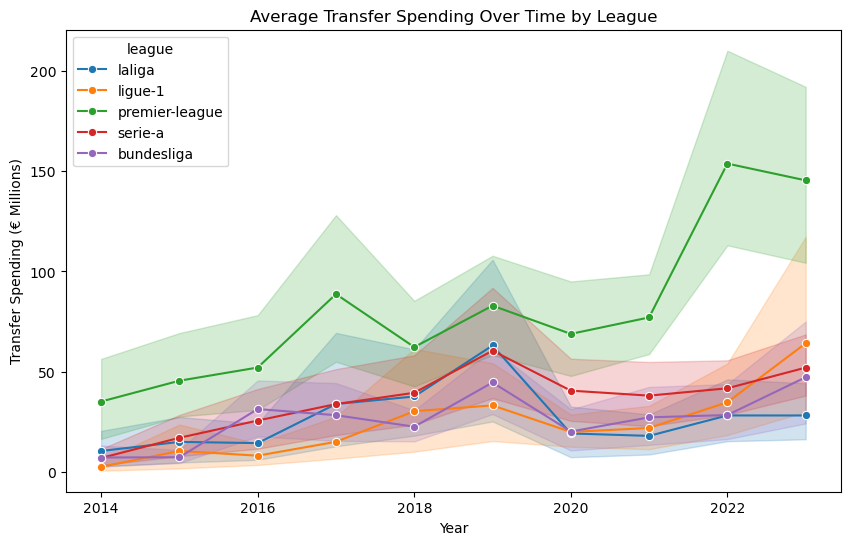

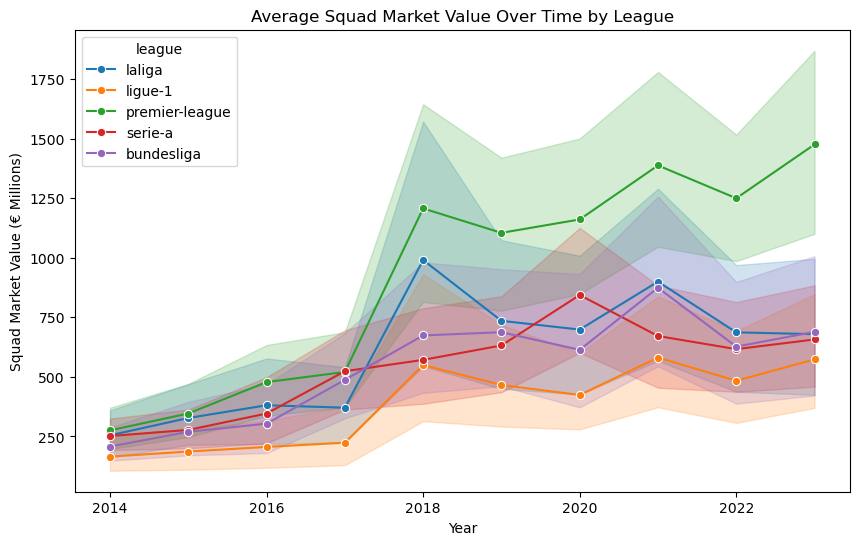

In [24]:
df['spending_m'] = df['transfer_spending'] / 1e6
df['svalue_m'] = df['squad_market_value'] / 1e6

# average transfer spending by league over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='spending_m', hue='league', estimator='mean', marker='o')
plt.title('Average Transfer Spending Over Time by League')
plt.xlabel('Year')
plt.ylabel('Transfer Spending (€ Millions)')
plt.show()

# average squad market value by league over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='svalue_m', hue='league', estimator='mean', marker='o')
plt.title('Average Squad Market Value Over Time by League')
plt.xlabel('Year')
plt.ylabel('Squad Market Value (€ Millions)')
plt.show()

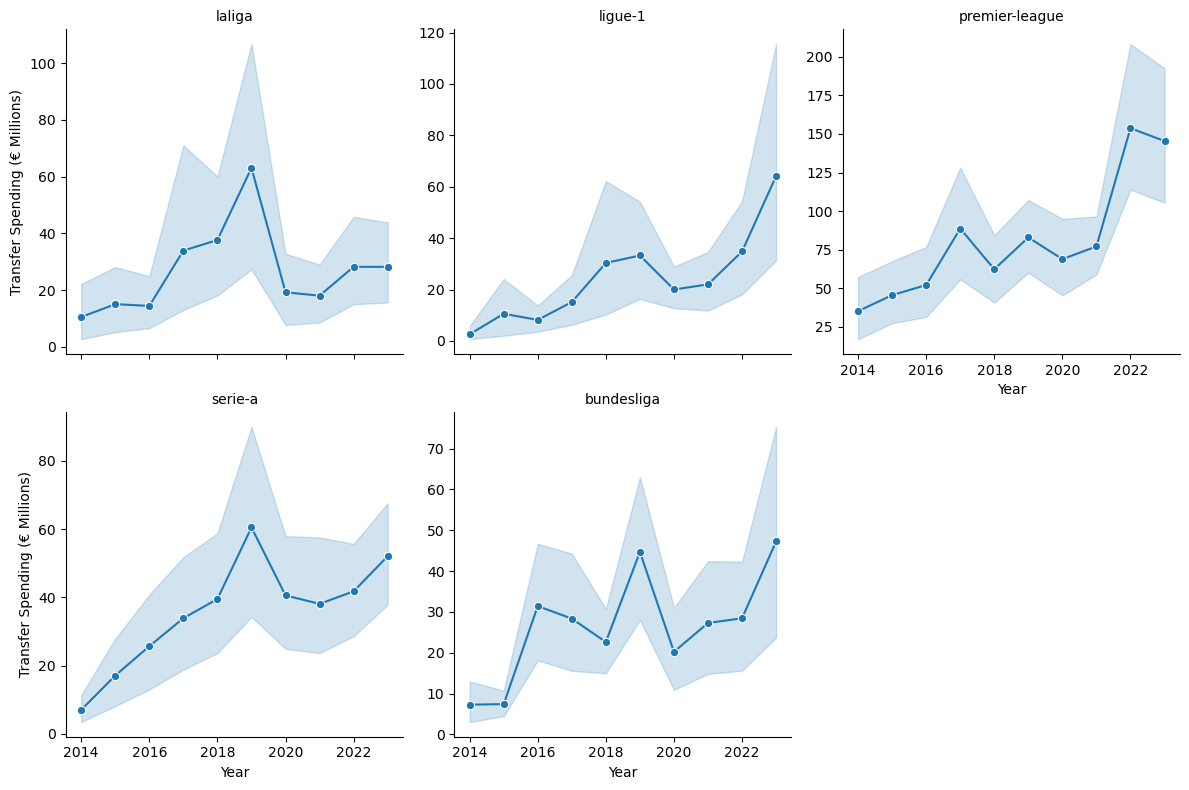

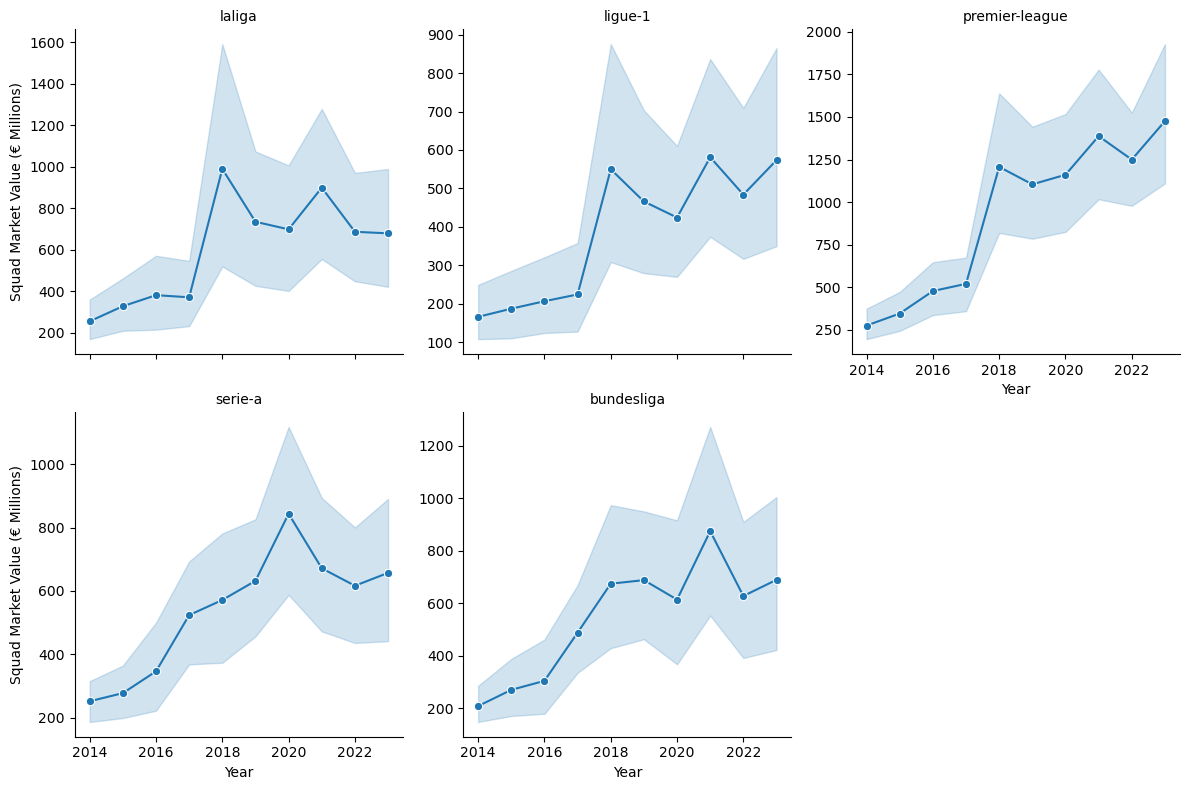

In [25]:
g = sns.FacetGrid(df, col='league', col_wrap=3, height=4, sharey=False)
g.map_dataframe(sns.lineplot, x='year', y='spending_m', estimator='mean', marker='o')
g.set_axis_labels('Year', 'Transfer Spending (€ Millions)')
g.set_titles('{col_name}')
plt.show()

g = sns.FacetGrid(df, col='league', col_wrap=3, height=4, sharey=False)
g.map_dataframe(sns.lineplot, x='year', y='svalue_m', estimator='mean', marker='o')
g.set_axis_labels('Year', 'Squad Market Value (€ Millions)')
g.set_titles('{col_name}')
plt.show()

- Transfer spending has grown significantly across all leagues over the decade.
- Squad values have inflated dramatically. The average club today is worth 2-3x what it was in 2014.
- The Premier League has accelerated the fastest. Its spending gap vs other leagues has widened since 2018.
- PSG signed Neymar for €222M in August 2017, shattering the world record. This single transfer didn't just move one player, it made all the clubs revalue their own squads upward. This is one of the factors that contributed to a steep rise in squad value in 2018 across all leagues.
- COVID (2020) caused a visible dip across all leagues. Most of the teams played indoors without fans in the stadiums and this crippled the teams' revenue influx.

### Top Clubs Analysis

In [26]:
df.groupby('club_name')['points'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

club_name
FC Barcelona              86.2
Manchester City           86.1
Real Madrid FC            84.9
Paris Saint-Germain FC    84.7
Juventus                  82.8
Bayern Munich             79.1
Atlético Madrid           77.9
Liverpool                 77.9
Napoli                    76.2
Inter Milan               74.8
Name: points, dtype: float64

- All the top 10 clubs are football giants and are backed by significant financial resources; no surprise names.
- PSG, Man City, Barcelona, Real Madrid, Juventus sit at the very top. These clubs are either state-backed or historically wealthy.
- This affirms the broad relationship between financial power and sustained success. 

### Financial strength vs Performance

#### Correlation Map

<Axes: >

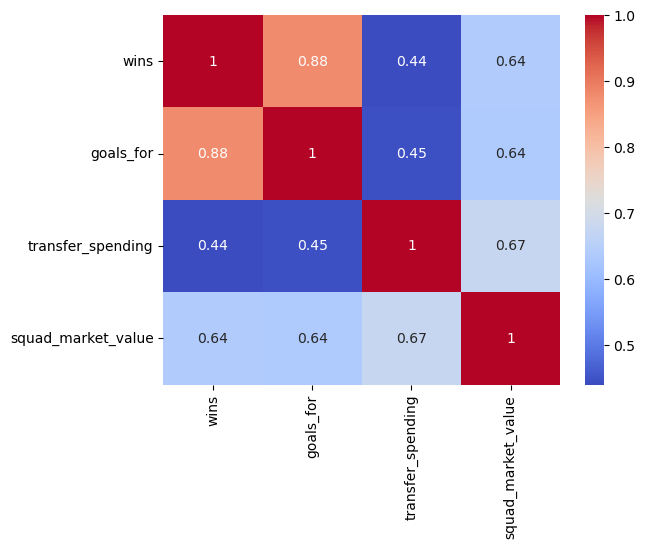

In [27]:
sns.heatmap(df[['wins','goals_for','transfer_spending','squad_market_value']].corr(),
            annot=True, cmap='coolwarm')

- Squad value has the strongest relationship with both wins and goals, more than transfer spending alone.
- Transfer spending and squad value are themselves strongly linked, meaning that the clubs that spend big tend to have valuable squads.
- The financial variables are more connected to each other than they are to the results / performance.

### Residual analysis (actual vs expected points) and Results

#### Based on Sqaud Value

In [32]:
# Predict points from squad value
X = df1[['squad_market_value']].fillna(0)
y = df1['points']

model = LinearRegression()
model.fit(X, y)
df1['predicted_points'] = model.predict(X).round(1)
df1['residual'] = (df1['points'] - df1['predicted_points']).round(1)

# Positive residual = overperformer (more points than expected)
# Negative residual = underperformer (fewer points than expected)

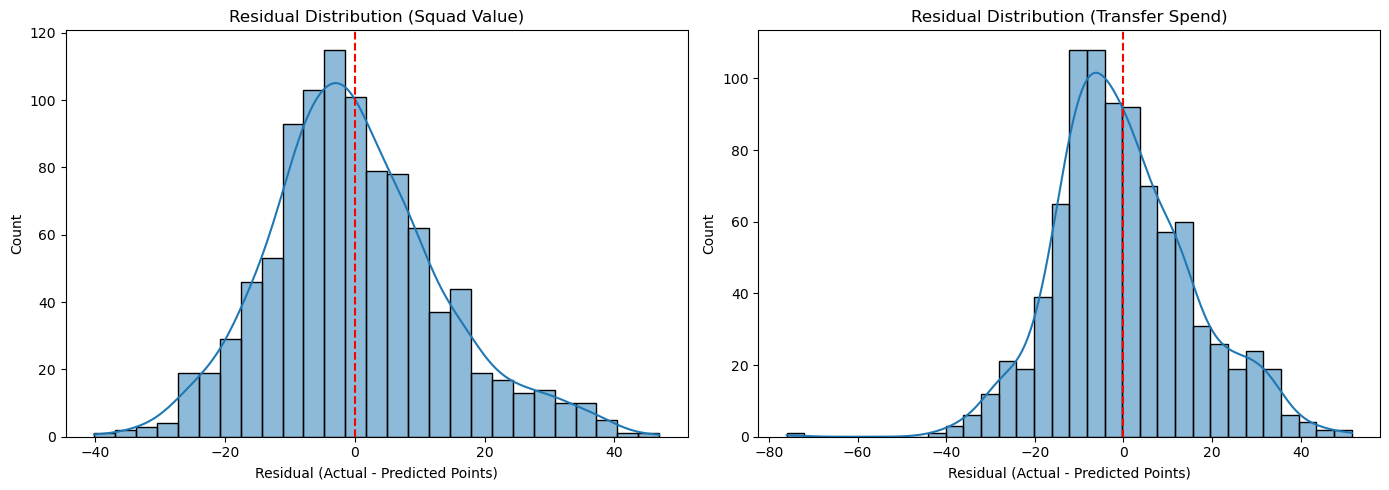

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df1['residual'], kde=True, ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution (Squad Value)')
axes[0].set_xlabel('Residual (Actual - Predicted Points)')

sns.histplot(df1['residual_spend'].dropna(), kde=True, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution (Transfer Spend)')
axes[1].set_xlabel('Residual (Actual - Predicted Points)')

plt.tight_layout()
plt.show()

- Most prediction errors are close to zero, meaning the model is generally balanced and not consistently over- or under-estimating team performance. 
- However, the errors can still be quite large (up to ±40 points), showing that money alone does not fully explain success. 
- Other factors like tactics, coaching, and team dynamics also play an important role.

##### Top Overperformers

In [33]:
print(f"\nTop 10 overperformers (highest residual):")
print(df1.nlargest(10, 'residual')[['club_name','league','season','points','predicted_points','residual']].to_string())


Top 10 overperformers (highest residual):
                  club_name          league   season  points  predicted_points  residual
263               Monaco FC         ligue-1  2016/17      95              48.1      46.9
334         Manchester City  premier-league  2017/18     100              58.8      41.2
232            FC Barcelona          laliga  2014/15      94              53.9      40.1
510  Paris Saint-Germain FC         ligue-1  2015/16      96              56.8      39.2
542                 Chelsea  premier-league  2014/15      87              48.3      38.7
694          Leicester City  premier-league  2015/16      81              43.4      37.6
480                Juventus         serie-a  2015/16      91              53.5      37.5
544                 Chelsea  premier-league  2016/17      93              55.9      37.1
937                  Napoli         serie-a  2016/17      86              49.1      36.9
452          Real Madrid FC          laliga  2014/15      92       

- Monaco 2016/17 - Biggest overperformer. They won Ligue 1 with 95 points despite a relatively modest squad value. (NOTE - This was the Mbappé/Lemar/Falcao generation before they sold everyone)
- Leicester 2015/16 - 81 points with a squad valued way below league average. They won the Championship that season.
- Man City 2017/18 - Interesting to spot them in the Top 10 Overperformers. Despite having a massive squad, they still overperformed their predicted points — this could be due to Guardiola's 100-point season that was genuinely exceptional even relative to their wealth.
- Chelsea appearing twice as overperformer (2014/15, 2016/17) — Mourinho's efficient Chelsea sides, depicts Manager's impact on the team.

##### Top 10 Underperformers

In [34]:
print(f"\nTop 10 underperformers (lowest residual):")
print(df1.nsmallest(10, 'residual')[['club_name','league','season','points','predicted_points','residual']].to_string())


Top 10 underperformers (lowest residual):
             club_name          league   season  points  predicted_points  residual
456     Real Madrid FC          laliga  2018/19      68             108.1     -40.1
550            Chelsea  premier-league  2022/23      44              79.4     -35.4
551            Chelsea  premier-league  2023/24      63              96.7     -33.7
129         Schalke 04      bundesliga  2020/21      16              48.6     -32.6
429           Toulouse         ligue-1  2019/20      13              44.7     -31.7
360   Sheffield United  premier-league  2023/24      16              47.1     -31.1
787  Huddersfield Town  premier-league  2018/19      16              46.3     -30.3
289     Southampton FC  premier-league  2022/23      25              54.5     -29.5
393        Salernitana         serie-a  2023/24      17              45.4     -28.4
790       Norwich City  premier-league  2021/22      22              49.4     -27.4


- Real Madrid 2018/19 - Biggest underperformer. This was the post-Ronaldo season, the team was still adjusting to it. (with Lopetegui/Solari chaos).
- Chelsea 2022/23 and 2023/24 — two consecutive massive underperformances (despite huge spending post-Abramovich sale).
- Schalke 2020/21 — relegated despite reasonable squad value. Financial collapse season.

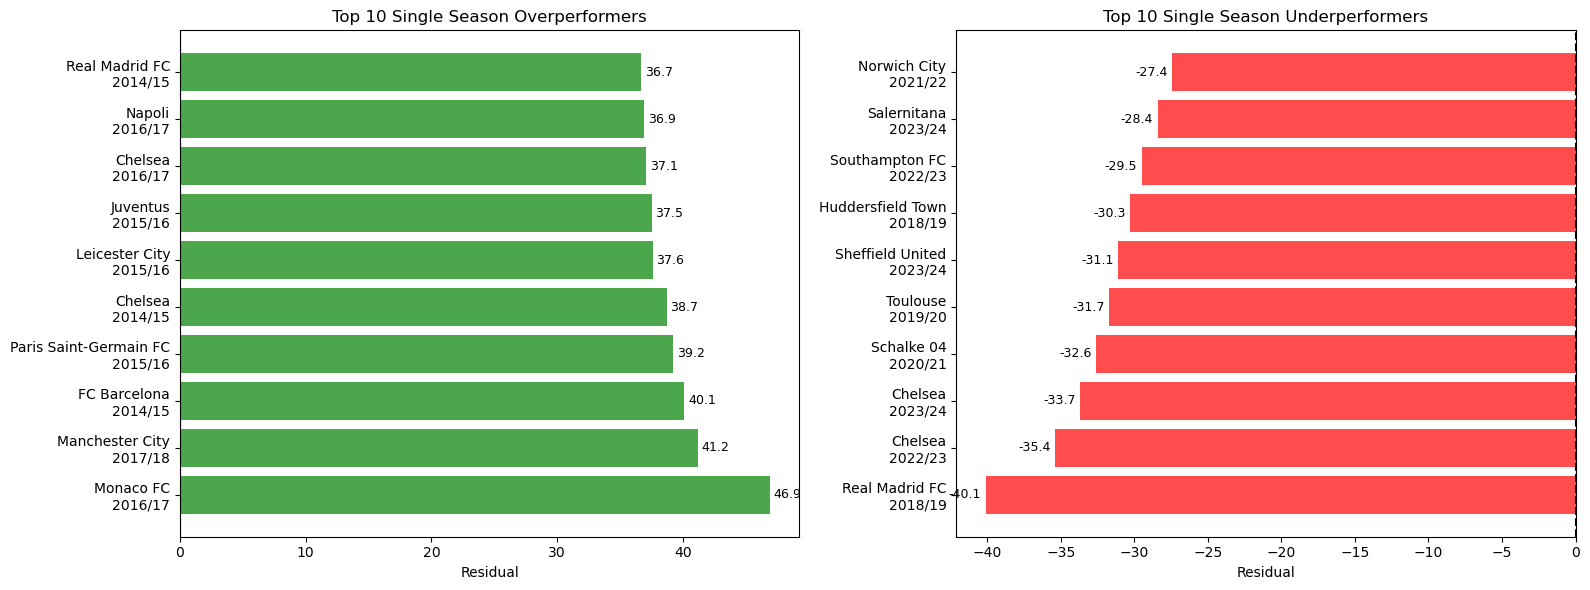

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Worst single seasons
worst = df1.nsmallest(10, 'residual')[['club_name', 'season', 'residual']].copy()
worst['label'] = worst['club_name'] + '\n' + worst['season'].astype(str)

# Best single seasons  
best = df1.nlargest(10, 'residual')[['club_name', 'season', 'residual']].copy()
best['label'] = best['club_name'] + '\n' + best['season'].astype(str)

# Plot best
axes[0].barh(best['label'], best['residual'], color='green', alpha=0.7)
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('Top 10 Single Season Overperformers')
axes[0].set_xlabel('Residual')
for i, v in enumerate(best['residual']):
    axes[0].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)

# Plot worst
axes[1].barh(worst['label'], worst['residual'], color='red', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Top 10 Single Season Underperformers')
axes[1].set_xlabel('Residual')
for i, v in enumerate(worst['residual']):
    axes[1].text(v - 0.3, i, f'{v:.1f}', ha='right', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Recommendation - 
- For lower-sqaud value clubs:
    - These teams can compete by focusing on smart recruitment and strong team structure, as shown by teams like Leicester and Monaco.

- For high-sqaud value clubs:
    - These teams should prioritize efficiency and performance management, as poor results despite high sqaud value represent significant inefficiencies.

##### Middle-East Owned Teams 

In [35]:
print(f"\nMiddle East owned clubs:")
print(df1[df1['middle_east_owned']==1][['club_name','year','points','squad_market_value','residual']].sort_values(['club_name','year']).to_string())


Middle East owned clubs:
                  club_name  year  points  squad_market_value  residual
331         Manchester City  2014      79           422900000      31.2
332         Manchester City  2015      66           483675000      17.1
333         Manchester City  2016      78           790650000      23.9
334         Manchester City  2017     100          1068450000      41.2
335         Manchester City  2018      98          3145775000       3.8
336         Manchester City  2019      81          2521925000      -2.6
337         Manchester City  2020      86          2459400000       3.5
338         Manchester City  2021      93          3163550000      -1.5
339         Manchester City  2022      89          2330575000       8.7
340         Manchester City  2023      91          3023425000      -1.1
594        Newcastle United  2021      49           775700000      -4.8
595        Newcastle United  2022      71          1089900000      11.8
596        Newcastle United  2023     

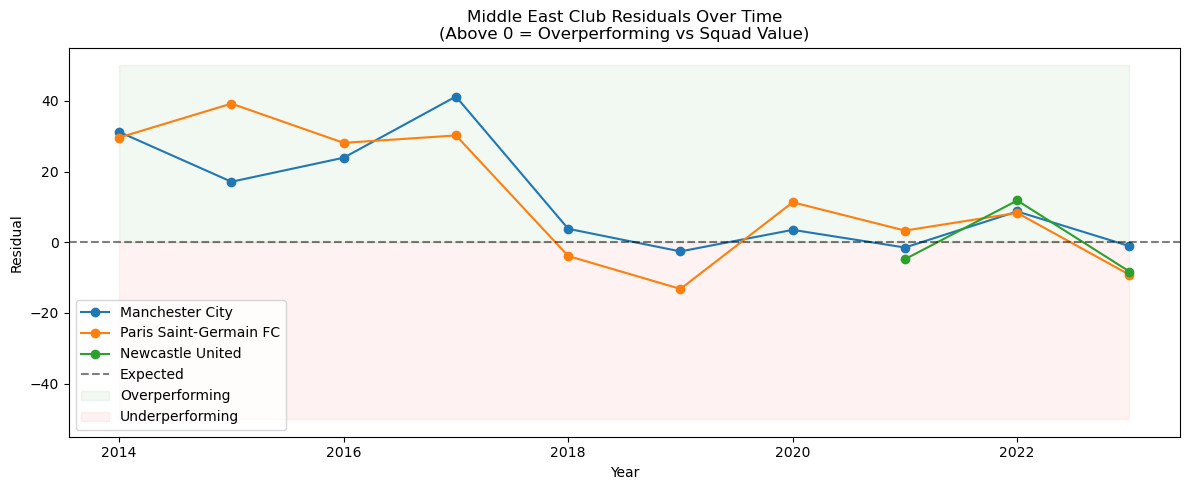

In [42]:
me_clubs = df1[df1['middle_east_owned']==1]

plt.figure(figsize=(12, 5))
for club in me_clubs['club_name'].unique():
    club_data = me_clubs[me_clubs['club_name']==club].sort_values('year')
    plt.plot(club_data['year'], club_data['residual'], 
             marker='o', label=club)

plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Expected')
plt.fill_between(me_clubs['year'].unique(), 0, 50, alpha=0.05, color='green', label='Overperforming')
plt.fill_between(me_clubs['year'].unique(), -50, 0, alpha=0.05, color='red', label='Underperforming')
plt.title('Middle East Club Residuals Over Time\n(Above 0 = Overperforming vs Squad Value)')
plt.xlabel('Year')
plt.ylabel('Residual')
plt.legend()
plt.tight_layout()
plt.show()

- Man City:

    - 2014–2017: strong overperformance (+17 to +41) — Guardiola era, money plus very good Manager
    - 2018 onwards: residuals near zero — squad SO expensive that even great performance barely beats the expectations

- Newcastle post-2021:

    - 2021: -4.8 - first season under new ownership
    - 2022: +11.8 - improving
    - 2023: -8.3 squad value growing faster than results

- PSG:

    - 2014–2017: consistently overperforming (+28 to +39) — money was buying results efficiently
    - 2018 onwards: residuals drop to near zero or negative — as squad value ballooned past €3B, returns diminished sharply
    - 2019: -13.2 — worst PSG season relative to investment
    - 2021 - 3.3 - Addition to Messi to the team inflated their sqaud value but results were no better




Recommmendations:

- For example, Manchester City and PSG initially overperformed during periods of investment, but as their squad values increased significantly, their performance aligned more closely with expectations. 

- While initial investment helps teams outperform expectations, continuously increasing squad value does not guarantee further performance gains. 

- So, going forward, clubs should focus less on simply increasing squad value and more on how efficiently current resources are used, including coaching quality, squad balance, and tactical fit

#### Based on Transfer Spend

In [36]:
# Only use clubs with transfer spending > 0
df1_spend = df1[df1['transfer_spending'] > 0].copy()

X_spend = df1_spend[['transfer_spending']]
y_spend = df1_spend['points']

model_spend = LinearRegression()
model_spend.fit(X_spend, y_spend)

df1_spend['predicted_points_spend'] = model_spend.predict(X_spend).round(1)
df1_spend['residual_spend'] = (df1_spend['points'] - df1_spend['predicted_points_spend']).round(1)

# Merge back
df1 = df1.merge(
    df1_spend[['club_id', 'year', 'predicted_points_spend', 'residual_spend']],
    on=['club_id', 'year'], how='left'
)

##### Top 10 Overperformers

In [37]:
print("Top 10 overperformers (highest residual):")
print(df1.nlargest(10, 'residual_spend')[
    ['club_name','league','season','transfer_spending','points','predicted_points_spend','residual_spend']
].to_string())

Top 10 overperformers (highest residual):
                  club_name          league   season  transfer_spending  points  predicted_points_spend  residual_spend
118               Liverpool  premier-league  2019/20         10400000.0      99                    47.5            51.5
335         Manchester City  premier-league  2018/19          9900000.0      98                    47.4            50.6
263               Monaco FC         ligue-1  2016/17         31000000.0      95                    50.1            44.9
512  Paris Saint-Germain FC         ligue-1  2017/18         16000000.0      93                    48.2            44.8
454          Real Madrid FC          laliga  2016/17         30000000.0      93                    50.0            43.0
232            FC Barcelona          laliga  2014/15         42000000.0      94                    51.6            42.4
452          Real Madrid FC          laliga  2014/15         35000000.0      92                    50.7            41.

- Liverpool 2019/20 — spent only €10.4M that season yet won the title with 99 points. (Klopp had a squad that was already built, zero new investment needed). Best value for money in the entire dataset.
- Man City 2018/19 — spent just €9.9M and got 98 points (Guardiola's effect).
- Monaco 2016/17 — spent €31M and got 95 points. (Youth academy resources).

##### Top 10 Underperformers

In [38]:
print("\nTop 10 underperformers (lowest residual):")
print(df1.nsmallest(10, 'residual_spend')[
    ['club_name','league','season','transfer_spending','points','predicted_points_spend','residual_spend']
].to_string())


Top 10 underperformers (lowest residual):
            club_name          league   season  transfer_spending  points  predicted_points_spend  residual_spend
550           Chelsea  premier-league  2022/23        574350000.0      44                   120.0           -76.0
551           Chelsea  premier-league  2023/24        464100000.0      63                   105.9           -42.9
289    Southampton FC  premier-league  2022/23        140210000.0      25                    64.2           -39.2
360  Sheffield United  premier-league  2023/24         66950000.0      16                    54.8           -38.8
798           Burnley  premier-league  2023/24        111050000.0      24                    60.4           -36.4
408       Aston Villa  premier-league  2015/16         52000000.0      17                    52.8           -35.8
406      Leeds United  premier-league  2022/23        156840000.0      31                    66.3           -35.3
231             Parma         serie-a  2020/2

- Chelsea 2022/23 (-76.0) — the most extreme underperformer in the entire dataset. Spent €574M — the highest single season spend in the dataset and got only 44 points.
- Chelsea 2023/24 (-42.9) — €464M spent, 63 points. Second consecutive disaster.

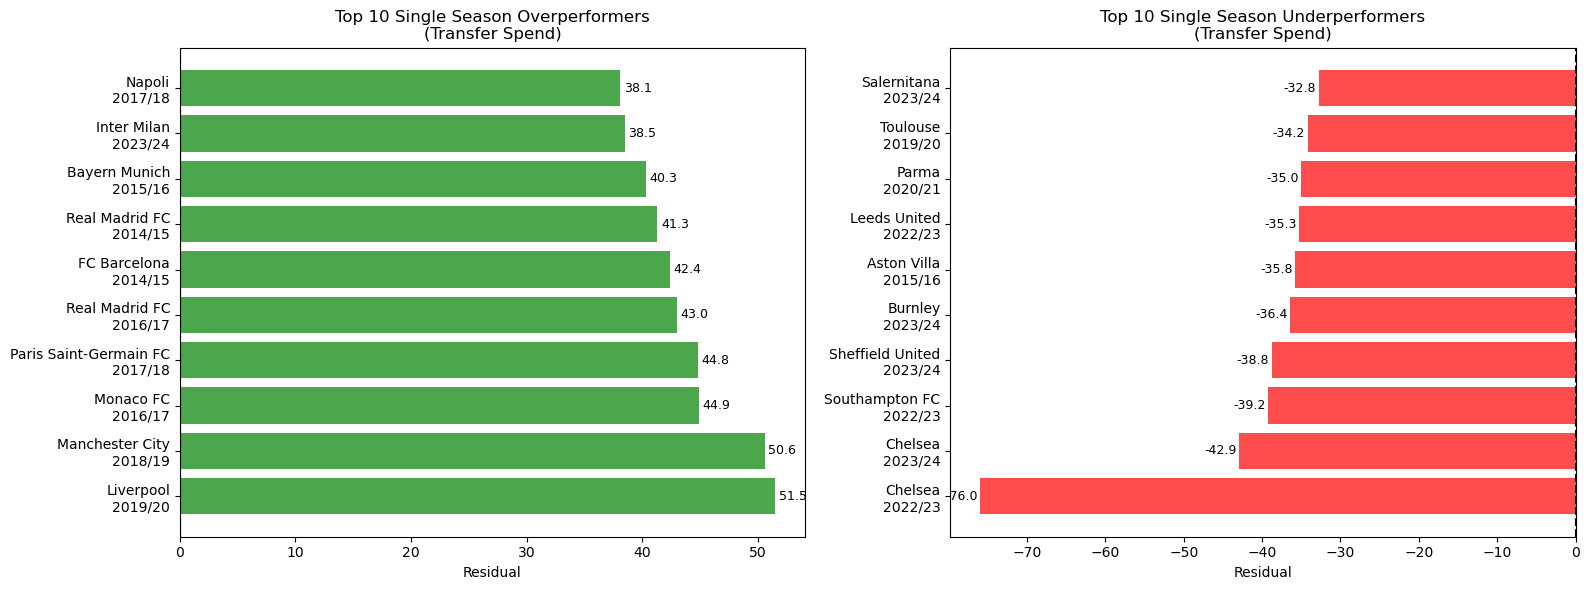

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

worst_spend = df1.nsmallest(10, 'residual_spend')[['club_name', 'season', 'residual_spend']].copy()
worst_spend['label'] = worst_spend['club_name'] + '\n' + worst_spend['season'].astype(str)

best_spend = df1.nlargest(10, 'residual_spend')[['club_name', 'season', 'residual_spend']].copy()
best_spend['label'] = best_spend['club_name'] + '\n' + best_spend['season'].astype(str)

# Plot best
axes[0].barh(best_spend['label'], best_spend['residual_spend'], color='green', alpha=0.7)
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('Top 10 Single Season Overperformers\n(Transfer Spend)')
axes[0].set_xlabel('Residual')
for i, v in enumerate(best_spend['residual_spend']):
    axes[0].text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)

# Plot worst
axes[1].barh(worst_spend['label'], worst_spend['residual_spend'], color='red', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Top 10 Single Season Underperformers\n(Transfer Spend)')
axes[1].set_xlabel('Residual')
for i, v in enumerate(worst_spend['residual_spend']):
    axes[1].text(v - 0.3, i, f'{v:.1f}', ha='right', va='center', fontsize=9)

plt.tight_layout()
plt.show()

##### Middle-East Owned Teams 

In [39]:
print("\nMiddle East owned clubs — transfer spend residuals:")
print(df1[df1['middle_east_owned']==1][[
    'club_name','year','season','transfer_spending',
    'points','predicted_points_spend','residual_spend'
]].sort_values(['club_name','year']).to_string())


Middle East owned clubs — transfer spend residuals:
                  club_name  year   season  transfer_spending  points  predicted_points_spend  residual_spend
331         Manchester City  2014  2014/15         60000000.0      79                    53.9            25.1
332         Manchester City  2015  2015/16        189450000.0      66                    70.5            -4.5
333         Manchester City  2016  2016/17        198250000.0      78                    71.7             6.3
334         Manchester City  2017  2017/18        313700000.0     100                    86.5            13.5
335         Manchester City  2018  2018/19          9900000.0      98                    47.4            50.6
336         Manchester City  2019  2019/20        165820000.0      81                    67.5            13.5
337         Manchester City  2020  2020/21        160900000.0      86                    66.9            19.1
338         Manchester City  2021  2021/22        138900000.0      

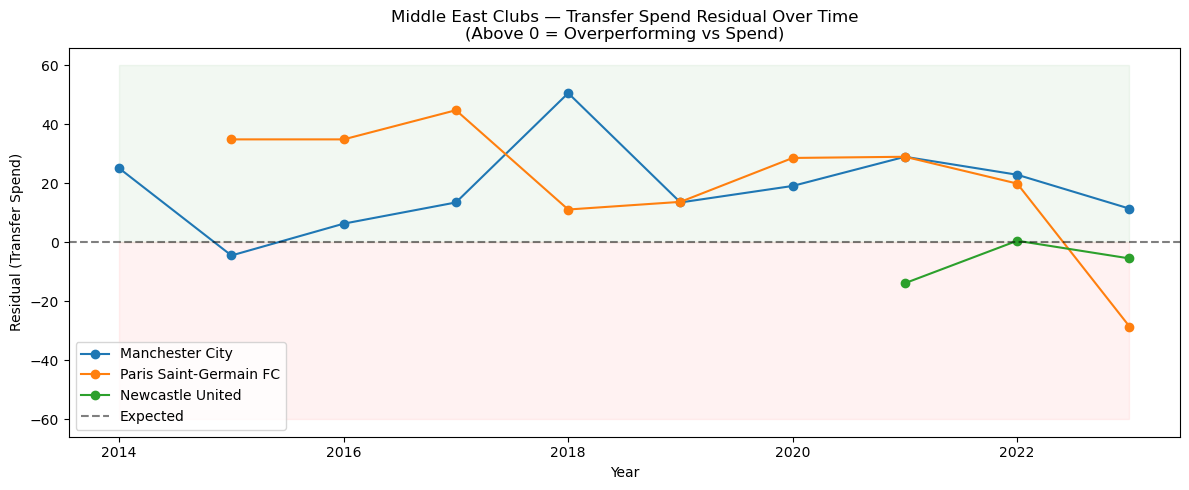

In [51]:
me_clubs = df1[df1['middle_east_owned'] == 1].copy()

plt.figure(figsize=(12, 5))

for club in me_clubs['club_name'].unique():
    club_data = me_clubs[me_clubs['club_name'] == club].sort_values('year')
    valid = club_data.dropna(subset=['residual_spend'])
    plt.plot(valid['year'], valid['residual_spend'], marker='o', label=club)

plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Expected')
plt.fill_between(sorted(me_clubs['year'].unique()), 0, 60, alpha=0.05, color='green')
plt.fill_between(sorted(me_clubs['year'].unique()), -60, 0, alpha=0.05, color='red')
plt.title('Middle East Clubs — Transfer Spend Residual Over Time\n(Above 0 = Overperforming vs Spend)')
plt.xlabel('Year')
plt.ylabel('Residual (Transfer Spend)')
plt.legend()
plt.tight_layout()
plt.show()

- Man City:

    - Generally positive throughout, shows that they are efficient spenders
    - 2015/16: -4.5 — their only negative season (transition to Guardiola)
    - 2018/19: +50.6 — basically didn't spend but won comfortably

- Newcastle:

    - 2021/22: -13.9 — first Saudi season, expected transitional chaos
    - 2022/23: +0.5 — breaking even, stabilising
    - 2023/24: -5.5 — still not getting full value from spending

- PSG:

    - 2015–2022: consistently positive (+11 to +44) — spending was efficient
    - 2023/24: -28.6 — spent €454M (their highest ever) and got only 76 points. Their worst value season by far. Also their 'Mbappé' departure year where money completely failed them

### Top Spender vs Title win

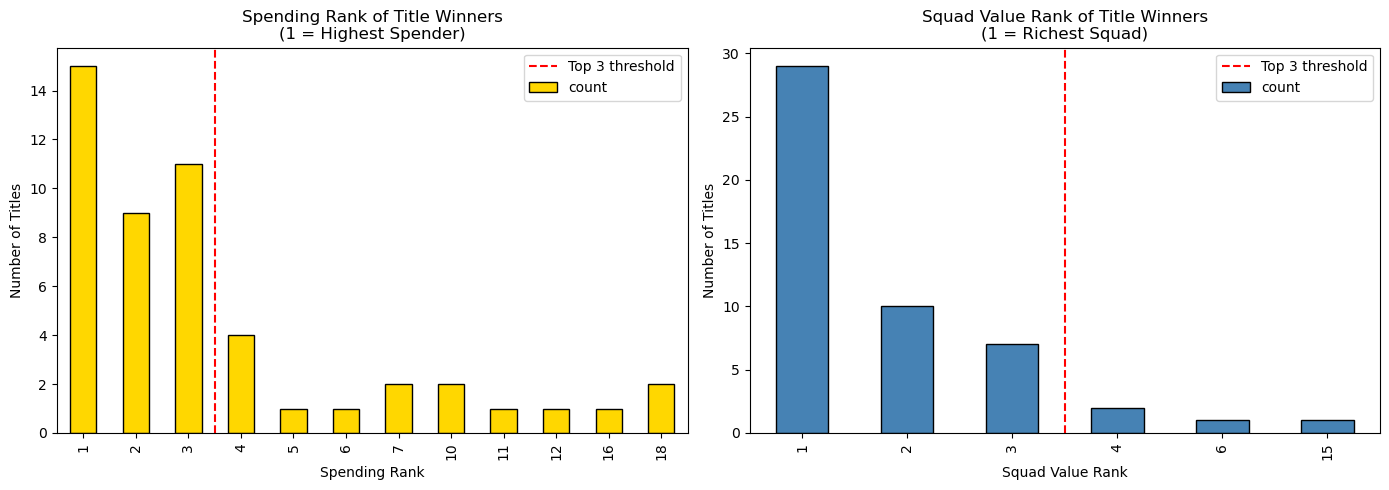

% of titles won by top spender:
30.0%

% of titles won by top 3 spenders:
70.0%

% of titles won by richest squad:
58.0%

By league:
league
bundesliga        80.0%
laliga            70.0%
ligue-1           60.0%
premier-league    50.0%
serie-a           90.0%
dtype: object


/var/folders/7q/2wc5cs997tqgvx852w8yrf1r0000gn/T/ipykernel_58902/1597097175.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(title_winners.groupby('league').apply(


In [52]:
# What % of titles were won by top 3 spenders?
title_winners = df1[df1['title_won'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spending rank of title winners
title_winners['spending_rank'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='gold', edgecolor='black'
)
axes[0].set_title('Spending Rank of Title Winners\n(1 = Highest Spender)')
axes[0].set_xlabel('Spending Rank')
axes[0].set_ylabel('Number of Titles')
axes[0].axvline(2.5, color='red', linestyle='--', label='Top 3 threshold')
axes[0].legend()

# Squad value rank of title winners
title_winners['value_rank'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('Squad Value Rank of Title Winners\n(1 = Richest Squad)')
axes[1].set_xlabel('Squad Value Rank')
axes[1].set_ylabel('Number of Titles')
axes[1].axvline(2.5, color='red', linestyle='--', label='Top 3 threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print the numbers
print("% of titles won by top spender:")
print(f"{(title_winners['spending_rank'] == 1).mean()*100:.1f}%")
print("\n% of titles won by top 3 spenders:")
print(f"{(title_winners['spending_rank'] <= 3).mean()*100:.1f}%")
print("\n% of titles won by richest squad:")
print(f"{(title_winners['value_rank'] == 1).mean()*100:.1f}%")
print("\nBy league:")
print(title_winners.groupby('league').apply(
    lambda x: (x['spending_rank'] <= 3).mean()*100
).round(1).astype(str) + '%')

- 30% of titles were won by the single highest spender. This is still far above random chance (5%, 1 in 20 teams), indicating that financial power provides a strong advantage.
- 70% of titles were won by one of the top 3 spenders. So financial power is a strong advantage.
- The richest squad wins the title 58% of the time. Squad value is more predictive than single-season spending on transfers. However, the remaining 42% of titles suggest that other factors such as managerial quality, tactics, and team cohesion, also play a crucial role. This is consistent with earlier findings, where some teams overperformed relative to their financial resources.

### Top Spender vs Champions League qualification (Top 4 finish)

/var/folders/7q/2wc5cs997tqgvx852w8yrf1r0000gn/T/ipykernel_58902/2135986695.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top4_by_spend = df1.groupby('spending_bucket')['top4_finish'].mean() * 100
/var/folders/7q/2wc5cs997tqgvx852w8yrf1r0000gn/T/ipykernel_58902/2135986695.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top4_by_value = df1.groupby('value_bucket')['top4_finish'].mean() * 100


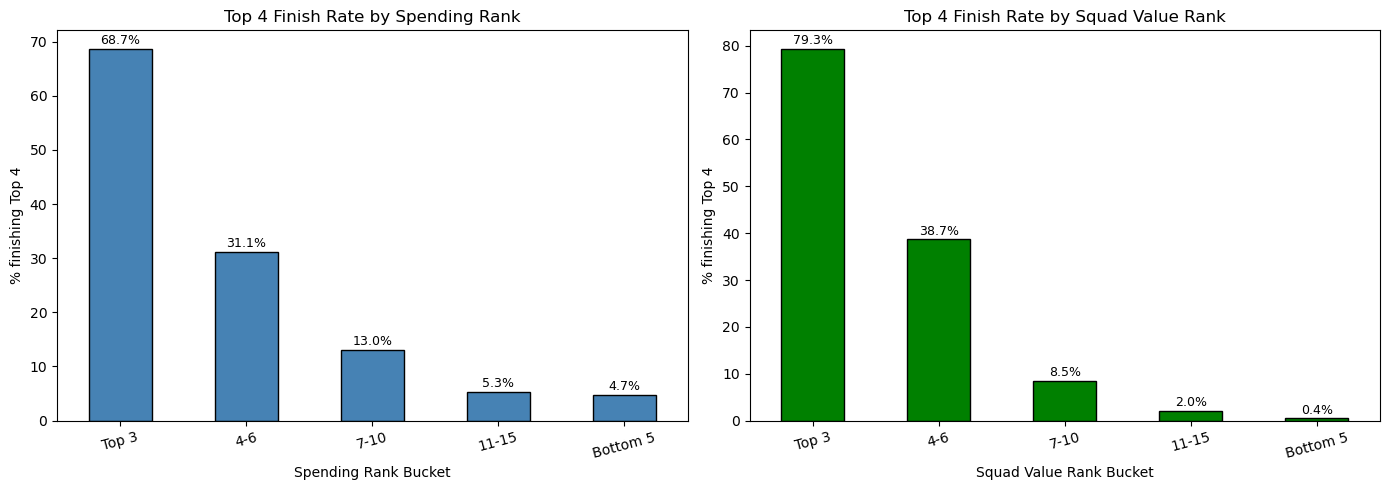

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 4 rate by spending rank bucket
df1['spending_bucket'] = pd.cut(
    df1['spending_rank'],
    bins=[0, 3, 6, 10, 15, 20],
    labels=['Top 3', '4-6', '7-10', '11-15', 'Bottom 5']
)

top4_by_spend = df1.groupby('spending_bucket')['top4_finish'].mean() * 100
top4_by_spend.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 4 Finish Rate by Spending Rank')
axes[0].set_xlabel('Spending Rank Bucket')
axes[0].set_ylabel('% finishing Top 4')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
for i, v in enumerate(top4_by_spend):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

# Top 4 rate by squad value rank bucket
df1['value_bucket'] = pd.cut(
    df1['value_rank'],
    bins=[0, 3, 6, 10, 15, 20],
    labels=['Top 3', '4-6', '7-10', '11-15', 'Bottom 5']
)

top4_by_value = df1.groupby('value_bucket')['top4_finish'].mean() * 100
top4_by_value.plot(kind='bar', ax=axes[1], color='green', edgecolor='black')
axes[1].set_title('Top 4 Finish Rate by Squad Value Rank')
axes[1].set_xlabel('Squad Value Rank Bucket')
axes[1].set_ylabel('% finishing Top 4')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
for i, v in enumerate(top4_by_value):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

- The top 3 spenders finish in the top 4 roughly 60-70% of the time. Money makes Champions League qualification likely but not certain.
- Beyond the top 3, the drop-off is sharp — mid-table spenders rarely break into the top 4.
- Squad value is a more reliable predictor of top 4 finishes than transfer spending.
- This shows that sustained investment beats seasonal splurges.

### Financial strength vs Relegation (demoted to second division)

/var/folders/7q/2wc5cs997tqgvx852w8yrf1r0000gn/T/ipykernel_58902/2682718687.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rel_by_spend = df1.groupby('spending_bucket')['relegated'].mean() * 100
/var/folders/7q/2wc5cs997tqgvx852w8yrf1r0000gn/T/ipykernel_58902/2682718687.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rel_by_value = df1.groupby('value_bucket')['relegated'].mean() * 100


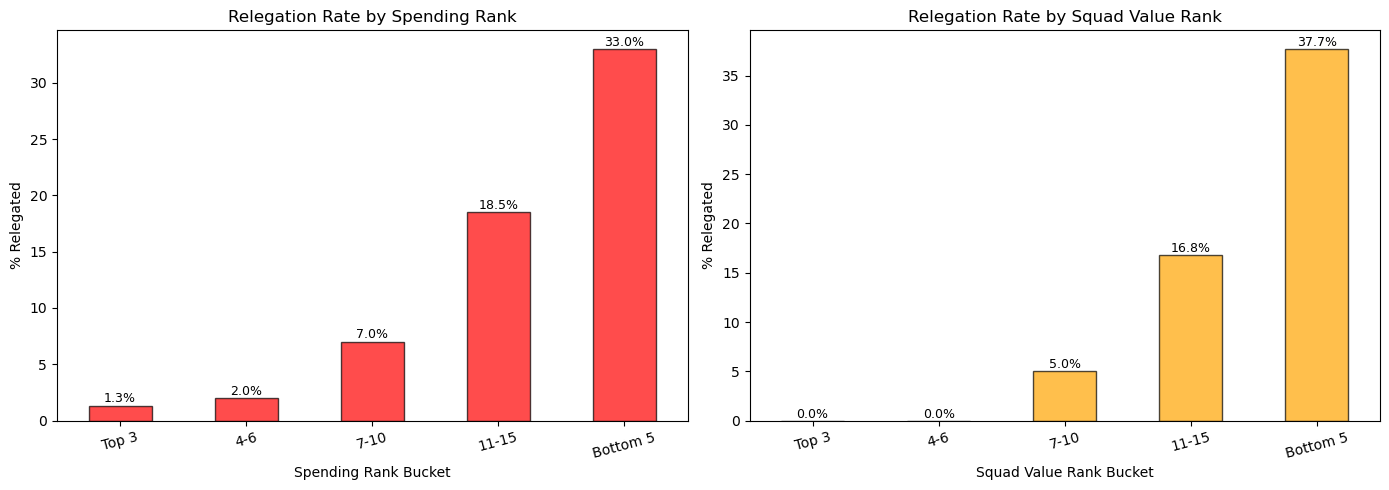

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Relegation rate by spending rank bucket
rel_by_spend = df1.groupby('spending_bucket')['relegated'].mean() * 100
rel_by_spend.plot(kind='bar', ax=axes[0], color='red', edgecolor='black', alpha=0.7)
axes[0].set_title('Relegation Rate by Spending Rank')
axes[0].set_xlabel('Spending Rank Bucket')
axes[0].set_ylabel('% Relegated')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
for i, v in enumerate(rel_by_spend):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# Relegation rate by squad value rank bucket
rel_by_value = df1.groupby('value_bucket')['relegated'].mean() * 100
rel_by_value.plot(kind='bar', ax=axes[1], color='orange', edgecolor='black', alpha=0.7)
axes[1].set_title('Relegation Rate by Squad Value Rank')
axes[1].set_xlabel('Squad Value Rank Bucket')
axes[1].set_ylabel('% Relegated')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
for i, v in enumerate(rel_by_value):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

- Bottom 5 spenders face a much higher relegation risk. Financial weakness directly correlates with survival battles.
- No club in the top 3 by squad value has been relegated.
- The middle tier (rank 7-15) shows the most variation and are inconsistent. These clubs can go either way regardless of spending.

### Importance of Financial strength in different Leagues 

/var/folders/7q/2wc5cs997tqgvx852w8yrf1r0000gn/T/ipykernel_58902/2747582913.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_by_league = df1.groupby('league').apply(
/var/folders/7q/2wc5cs997tqgvx852w8yrf1r0000gn/T/ipykernel_58902/2747582913.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_by_league, x='league', y='correlation', palette='coolwarm')


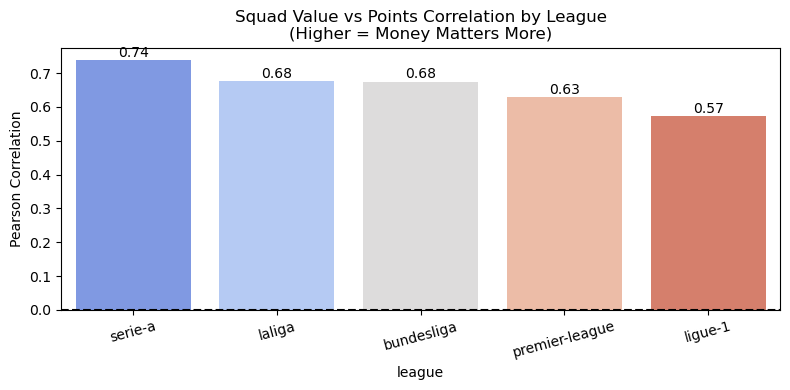

In [56]:
# Correlation between squad value and points per league
corr_by_league = df1.groupby('league').apply(
    lambda x: x['squad_market_value'].corr(x['points'])
).round(3).sort_values(ascending=False).reset_index()
corr_by_league.columns = ['league', 'correlation']

plt.figure(figsize=(8, 4))
sns.barplot(data=corr_by_league, x='league', y='correlation', palette='coolwarm')
plt.axhline(0, color='black', linestyle='--')
plt.title('Squad Value vs Points Correlation by League\n(Higher = Money Matters More)')
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=15)
for i, row in corr_by_league.iterrows():
    plt.text(i, row['correlation'] + 0.01, f'{row["correlation"]:.2f}',
             ha='center', fontsize=10)
plt.tight_layout()
plt.show()

- Serie A has the strongest link between squad value and points (0.74). In Italy, financial strength is the most reliable predictor of where the teams finish.
- La Liga and Bundesliga are almost identical (0.68). Money matters significantly in both, but there's still room for tactical and managerial quality to make a difference.
- The Premier League (0.63) shows a weaker link despite being the wealthiest league. Its financial competitiveness means having a valuable squad doesn't automatically translate to points.
- Ligue 1 has the lowest correlation (0.57). This is surprising given PSG's dominance, but it suggests the rest of the league is unpredictable enough to weaken the overall relationship.
- Across all leagues the correlation is positive and meaningful. Money always matters, but how much varies significantly by league.

### Sqaud value growth vs Points change (next season)

Correlation between squad value growth and points change: -0.035


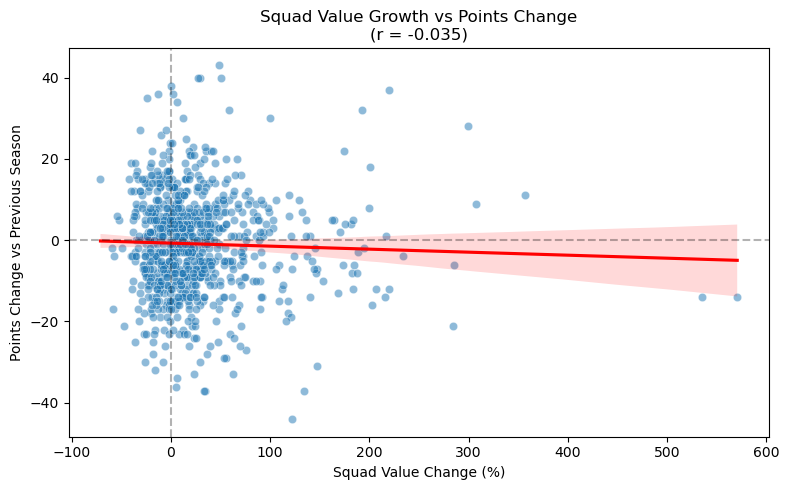

In [57]:
# Do clubs that invest heavily (grow squad value) improve their points next season?
valid = df1.dropna(subset=['squad_value_change_pct', 'points_change'])
corr = valid['squad_value_change_pct'].corr(valid['points_change'])
print(f"Correlation between squad value growth and points change: {corr:.3f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=valid, x='squad_value_change_pct', y='points_change', alpha=0.5)
sns.regplot(data=valid, x='squad_value_change_pct', y='points_change',
            scatter=False, color='red')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.title(f'Squad Value Growth vs Points Change\n(r = {corr:.3f})')
plt.xlabel('Squad Value Change (%)')
plt.ylabel('Points Change vs Previous Season')
plt.tight_layout()
plt.show()

- Correlation is -0.035 (alost zero). This means that growing the squad value in one season does NOT reliably improve the points the following season.
- So, investing heavily to build squad value doesn't translate to immediate results.

#### How often higher squad value leads to better performance? (higher = relative comparisons between two teams)

In [75]:
def squad_value_success_rate(df_league):
    pairs = list(itertools.combinations(df_league.index, 2))
    correct = 0
    total = 0
    
    for i, j in pairs:
        s1, s2 = df_league.loc[i, 'svalue_m'], df_league.loc[j, 'svalue_m']
        p1, p2 = df_league.loc[i, 'points'], df_league.loc[j, 'points']
        
        if s1 != s2:
            total += 1
            if (s1 > s2 and p1 > p2) or (s2 > s1 and p2 > p1):
                correct += 1
                
    return correct / total

df.groupby('league').apply(squad_value_success_rate)

/var/folders/7q/2wc5cs997tqgvx852w8yrf1r0000gn/T/ipykernel_58902/3863163794.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('league').apply(squad_value_success_rate)


league
bundesliga        0.693048
laliga            0.734874
ligue-1           0.675383
premier-league    0.703317
serie-a           0.761859
dtype: float64

🇩🇪 Bundesliga
- Squad value predicts performance in approximately 69–70% of cases, but with more concentrated spending levels, leading to a more balanced competitive structure compared to other leagues.

🇪🇸 La Liga
- Higher squad value leads to better performance in around 68–73% of cases, indicating a strong financial advantage. 
- However, the remaining cases show that lower-valued teams can still compete, highlighting some variability.”

🇫🇷 Ligue 1
- Squad value predicts performance in roughly 65–68% of cases, but the league is highly skewed, with a few dominant high-value teams and many lower-value teams. 
- This limits competitiveness at the top.

🇬🇧 Premier League
- Despite strong financial power, squad value only translates into better performance in about 65–70% of cases, reflecting high competition and variability even among top-spending teams.

🇮🇹 Serie A
- Serie A shows one of the strongest relationships, with squad value predicting performance in around 70–76% of cases, suggesting that financial strength is a particularly strong driver of success.

_____________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________________

# Data Quality Bias Analysis

In [ ]:
df_transfers = pd.read_csv("../data/raw/transf_perf/transfers.csv")
df_final = pd.read_csv("../data/intermediate/transf_perf.csv")

# Filter to scope and attach league
transfers = df_transfers.copy()
season_start = transfers['transfer_season'].astype(str).str.split('/').str[0]
transfers['season'] = season_start.astype(int)
transfers.loc[transfers['season'] < 100, 'season'] += 2000
transfers = transfers[(transfers['season'] >= 2014) & (transfers['season'] <= 2023)]
transfers['transfer_fee'] = pd.to_numeric(transfers['transfer_fee'], errors='coerce')

# Attach league and club name
club_league = df_final[['club_id', 'club_name', 'competition_id']].drop_duplicates()
transfers = transfers.merge(club_league, left_on='to_club_id', right_on='club_id', how='left')
in_scope = transfers[transfers['competition_id'].notna()].copy()

# NULL rate by league 
league_bias = in_scope.groupby('competition_id').apply(lambda x: pd.Series({
    'total_transfers': len(x),
    'null_count': x['transfer_fee'].isna().sum(),
    'null_pct': x['transfer_fee'].isna().sum() / len(x) * 100
}), include_groups=False).round(1).sort_values('null_pct', ascending=False)

print("=== NULL rate by league ===")
print(league_bias)

# NULL rate by club (min 10 transfers)
club_bias = in_scope.groupby(['club_name', 'competition_id']).apply(lambda x: pd.Series({
    'total_transfers': len(x),
    'null_count': x['transfer_fee'].isna().sum(),
    'null_pct': x['transfer_fee'].isna().sum() / len(x) * 100
}), include_groups=False).reset_index()
club_bias = (club_bias[club_bias['total_transfers'] >= 10]
             .sort_values('null_pct', ascending=False)
             .round(1))

print("\n=== Top 15 most affected clubs ===")
print(club_bias.head(15).to_string(index=False))

# NULL rate by year 
year_bias = in_scope.groupby('season').apply(lambda x: pd.Series({
    'total_transfers': len(x),
    'null_count': x['transfer_fee'].isna().sum(),
    'null_pct': x['transfer_fee'].isna().sum() / len(x) * 100
}), include_groups=False).round(1)

print("\n=== NULL rate by year ===")
print(year_bias)

# Players with most undisclosed fees
player_bias = (in_scope[in_scope['transfer_fee'].isna()]
               .groupby('player_name')
               .size()
               .reset_index(name='undisclosed_count')
               .sort_values('undisclosed_count', ascending=False))

print("\n=== Players with most undisclosed fees ===")
print(player_bias.head(15).to_string(index=False))

=== NULL rate by league ===
                total_transfers  null_count  null_pct
competition_id                                       
FR1                      2507.0       548.0      21.9
ES1                      2523.0       365.0      14.5
L1                       2181.0       307.0      14.1
GB1                      3388.0       369.0      10.9
IT1                      3752.0       276.0       7.4

=== Top 15 most affected clubs ===
                            club_name competition_id  total_transfers  null_count  null_pct
               Le Havre Athletic Club            FR1             66.0        29.0      43.9
                            SC Bastia            FR1             23.0        10.0      43.5
                          EA Guingamp            FR1             42.0        18.0      42.9
                 Athletic Club Bilbao            ES1             65.0        26.0      40.0
Association de la Jeunesse auxerroise            FR1             48.0        16.0      33.3
      

- Leagues: Ligue 1 (French league) is the most biased at 21.9%. Serie A and Premier League are the most reliable.

- Clubs: The top 14 most affected clubs are almost entirely Ligue 1 and La Liga - Smaller clubs like Le Havre (43.9%), Guingamp (42.9%), Athletic Bilbao (40%). These clubs' spending is most understated. Notably these are mid/lower table clubs, not big spenders, so the bias likely doesn't distort headline spending comparisons significantly.

- Years: 2020 stands out at 14.7%. The COVID caused this, but otherwise stable at 11–15%.

- Players: No player exceeds 3 undisclosed fees. The missing data is spread thin across many players, not concentrated on superstars. There's no single high-profile player skewing the numbers systematically.